# Static `geom_livemap()`

The `interactive` parameter controls whether a livemap can be dragged and zoomed. By default, `geom_livemap()` is interactive. Set `interactive=False` to show a fixed map with no zoom controls.

The geodata is provided by © OpenStreetMap contributors and is made available here under the Open Database License (ODbL).



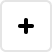
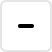
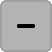
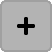
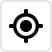
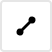
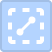
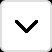
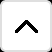
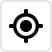
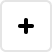
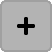
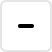
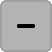
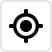
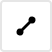
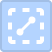
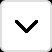
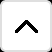
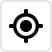

In [1]:
from lets_plot import *
from lets_plot import tilesets
from lets_plot.geo_data import *

LetsPlot.setup_html()

In [2]:
cities = {
    'city': ['Seattle', 'Portland', 'San Francisco', 'Los Angeles', 'San Diego'],
    'state': ['Washington', 'Oregon', 'California', 'California', 'California'],
}

centroids = geocode_cities(cities['city']).states(cities['state']).scope('USA').get_centroids()
route_points = centroids.set_index('city').loc[cities['city']]
route_data = {
    'city': route_points.index.tolist(),
    'lon': route_points.geometry.x.tolist(),
    'lat': route_points.geometry.y.tolist(),
}

route = geom_path(
    aes('lon', 'lat'),
    data=route_data,
    color='royal-blue / 0.7',
    size=1.2,
)
points = geom_point(
    data=cities,
    map=centroids,
    map_join='city',
    color='dark-orange / 0.9',
    size=6,
    tooltips=layer_tooltips().line('@city'),
)
plot_size = ggsize(520, 360)

## Default interactive map

The map can be panned and zoomed, and the zoom controls are visible.

In [3]:
ggplot() + geom_livemap(
    location=[-125, 32, -116, 49],
    tiles=tilesets.CARTO_POSITRON,
) + route + points + plot_size + ggtitle('interactive=True')

## Fixed map

With `interactive=False`, users can inspect the layer tooltips but cannot change the map viewport.

In [4]:
ggplot() + geom_livemap(
    location=[-125, 32, -116, 49],
    tiles=tilesets.CARTO_POSITRON,
    
    interactive=False,               # <----
    
) + route + points + plot_size + ggtitle('interactive=False')